# **Kaggle – DataTops®**
Tu TA ha decidido cambiar de aires y, por eso, ha comprado una tienda de portátiles. Sin embargo, su única especialidad es Data Science, por lo que ha decidido crear un modelo de ML para establecer los mejores precios.

¿Podrías ayudar a tu profe a mejorar ese modelo?

## Aspectos importantes
- Última submission:
    - Mañana: 17 de febrero a las 5pm
    - Tarde: 19 de febrero a las 5pm
- **Enlace de la competición**: https://www.kaggle.com/t/c5cc87b50c4b4770bdc8f5acbe15577d
- **Requisito**: Estar registrado en [Kaggle](https://www.kaggle.com/)

## Métrica:
El error cuadrático medio (RMSE, por sus siglas en inglés) es una medida de la desviación estándar de los residuos (errores de predicción). Los residuos representan la diferencia entre los valores observados y los valores predichos por el modelo. El RMSE indica qué tan dispersos están estos errores: cuanto menor es el RMSE, más cercanas están las predicciones a los valores reales. En otras palabras, el RMSE mide qué tan bien se ajusta la línea de regresión a los datos.


$$ RMSE = \sqrt{\frac{1}{n}\Sigma_{i=1}^{n}{\Big(\frac{d_i -f_i}{\sigma_i}\Big)^2}}$$


## 1. Librerías

In [1]:
import numpy as np
import pandas as pd
from PIL import Image
import toolbox_ML as tool
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
import urllib.request

## 2. Datos

In [2]:
# Para que funcione necesitas bajarte los archivos de datos de Kaggle
df = pd.read_csv("./data/train.csv", index_col= "laptop_ID")

### 2.1 Exploración de los datos

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 912 entries, 755 to 229
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           912 non-null    object 
 1   Product           912 non-null    object 
 2   TypeName          912 non-null    object 
 3   Inches            912 non-null    float64
 4   ScreenResolution  912 non-null    object 
 5   Cpu               912 non-null    object 
 6   Ram               912 non-null    object 
 7   Memory            912 non-null    object 
 8   Gpu               912 non-null    object 
 9   OpSys             912 non-null    object 
 10  Weight            912 non-null    object 
 11  Price_in_euros    912 non-null    float64
dtypes: float64(2), object(10)
memory usage: 92.6+ KB


In [4]:
df.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
755,HP,250 G6,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.86kg,539.00
618,Dell,Inspiron 7559,Gaming,15.6,Full HD 1920x1080,Intel Core i7 6700HQ 2.6GHz,16GB,1TB HDD,Nvidia GeForce GTX 960<U+039C>,Windows 10,2.59kg,879.01
909,HP,ProBook 450,Notebook,15.6,Full HD 1920x1080,Intel Core i7 7500U 2.7GHz,8GB,1TB HDD,Nvidia GeForce 930MX,Windows 10,2.04kg,900.00
2,Apple,Macbook Air,Ultrabook,13.3,1440x900,Intel Core i5 1.8GHz,8GB,128GB Flash Storage,Intel HD Graphics 6000,macOS,1.34kg,898.94
286,Dell,Inspiron 3567,Notebook,15.6,Full HD 1920x1080,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,AMD Radeon R5 M430,Linux,2.25kg,428.00


In [5]:
df.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight,Price_in_euros
laptop_ID,,,,,,,,,,,,
28,Dell,Inspiron 5570,Notebook,15.6,Full HD 1920x1080,Intel Core i5 8250U 1.6GHz,8GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,800.00
1160,HP,Spectre Pro,2 in 1 Convertible,13.3,Full HD / Touchscreen 1920x1080,Intel Core i5 6300U 2.4GHz,8GB,256GB SSD,Intel HD Graphics 520,Windows 10,1.48kg,1629.00
78,Lenovo,IdeaPad 320-15IKBN,Notebook,15.6,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,2TB HDD,Intel HD Graphics 620,No OS,2.2kg,519.00
23,HP,255 G6,Notebook,15.6,1366x768,AMD E-Series E2-9000e 1.5GHz,4GB,500GB HDD,AMD Radeon R2,No OS,1.86kg,258.00
229,Dell,Alienware 17,Gaming,17.3,IPS Panel Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,256GB SSD + 1TB HDD,Nvidia GeForce GTX 1060,Windows 10,4.42kg,2456.34


In [6]:
df.describe()

,Inches,Price_in_euros
count,912.000000,912.000000
mean,14.981579,1111.724090
std,1.436719,687.959172
min,10.100000,174.000000
25%,14.000000,589.000000
50%,15.600000,978.000000
75%,15.600000,1483.942500
max,18.400000,6099.000000


In [7]:
df.columns = df.columns.str.lower()
print(df.columns)

Index(['company', 'product', 'typename', 'inches', 'screenresolution', 'cpu',
       'ram', 'memory', 'gpu', 'opsys', 'weight', 'price_in_euros'],
      dtype='object')


In [8]:
tool.describe_df(df)

,data_type,valores_nulos,valores_unicos,cardinalidad_ptg
company,categorica,0.0,19,2.08
product,categorica,0.0,480,52.63
typename,categorica,0.0,6,0.66
inches,numerica,0.0,17,1.86
screenresolution,categorica,0.0,36,3.95
cpu,categorica,0.0,107,11.73
ram,categorica,0.0,9,0.99
memory,categorica,0.0,37,4.06
gpu,categorica,0.0,93,10.2
opsys,categorica,0.0,9,0.99


In [9]:
print(df.ram.value_counts())

ram
8GB     434
4GB     267
16GB    136
6GB      24
2GB      20
12GB     19
32GB     10
64GB      1
24GB      1
Name: count, dtype: int64


In [10]:
df["ram_num"]= df["ram"].str.replace("GB", "")
df["ram_num"] = df["ram_num"].astype(int)
df["weight"]= df["weight"].str.lower()
df["weight_num"]= df["weight"].str.replace("kg", "")
df["weight_num"] = df["weight_num"].astype(float)

In [11]:
print(list(df.screenresolution.unique()))

['Full HD 1920x1080', '1440x900', '1366x768', 'IPS Panel Full HD 1920x1080', 'IPS Panel 4K Ultra HD 3840x2160', 'IPS Panel Retina Display 2560x1600', 'Touchscreen 1366x768', 'IPS Panel Quad HD+ 2560x1440', 'IPS Panel 1366x768', 'Full HD / Touchscreen 1920x1080', 'IPS Panel Full HD 2160x1440', 'Quad HD+ 3200x1800', '4K Ultra HD / Touchscreen 3840x2160', 'IPS Panel Retina Display 2304x1440', 'IPS Panel Full HD / Touchscreen 1920x1080', 'IPS Panel Touchscreen 1920x1200', 'IPS Panel Touchscreen 2560x1440', 'Touchscreen 2400x1600', 'IPS Panel 4K Ultra HD / Touchscreen 3840x2160', 'IPS Panel Full HD 2560x1440', 'Quad HD+ / Touchscreen 3200x1800', '4K Ultra HD 3840x2160', 'IPS Panel Quad HD+ / Touchscreen 3200x1800', 'Touchscreen 2256x1504', '1600x900', 'IPS Panel Touchscreen 1366x768', 'Touchscreen / Quad HD+ 3200x1800', 'IPS Panel 2560x1440', 'IPS Panel Quad HD+ 3200x1800', 'Touchscreen 2560x1440', '2560x1440', 'IPS Panel Retina Display 2880x1800', 'Touchscreen / 4K Ultra HD 3840x2160', '19

In [12]:
# df.ScreenResolution.isin(["IPS Panel Full HD 2560x1440"]) ---> Dice False cuando no coincide y True cuando si
print(df[df.screenresolution == "IPS Panel Full HD 2560x1440"])
print(df[df.screenresolution == "IPS Panel Quad HD+ 2560x1440"])

          company         product   typename  inches  \
laptop_ID                                              
418        Lenovo  Thinkpad T470p  Ultrabook    14.0   

                      screenresolution                          cpu  ram  \
laptop_ID                                                                  
418        IPS Panel Full HD 2560x1440  Intel Core i7 7700HQ 2.8GHz  8GB   

              memory                      gpu       opsys weight  \
laptop_ID                                                          
418        512GB SSD  Nvidia GeForce GT 940MX  Windows 10  1.7kg   

           price_in_euros  ram_num  weight_num  
laptop_ID                                       
418                1943.0        8         1.7  
          company         product   typename  inches  \
laptop_ID                                              
728        Lenovo     ThinkPad X1  Ultrabook    14.0   
476        Lenovo  Thinkpad T460s  Ultrabook    14.0   
840        Lenovo     Thin

In [13]:
df.screenresolution = df.screenresolution.replace({
    "IPS Panel Full HD 2560x1440"   : "IPS Panel 2560x1440",
    "IPS Panel Quad HD+ 2560x1440"  : "IPS Panel 2560x1440"
})
print(list(df.screenresolution.unique()))

['Full HD 1920x1080', '1440x900', '1366x768', 'IPS Panel Full HD 1920x1080', 'IPS Panel 4K Ultra HD 3840x2160', 'IPS Panel Retina Display 2560x1600', 'Touchscreen 1366x768', 'IPS Panel 2560x1440', 'IPS Panel 1366x768', 'Full HD / Touchscreen 1920x1080', 'IPS Panel Full HD 2160x1440', 'Quad HD+ 3200x1800', '4K Ultra HD / Touchscreen 3840x2160', 'IPS Panel Retina Display 2304x1440', 'IPS Panel Full HD / Touchscreen 1920x1080', 'IPS Panel Touchscreen 1920x1200', 'IPS Panel Touchscreen 2560x1440', 'Touchscreen 2400x1600', 'IPS Panel 4K Ultra HD / Touchscreen 3840x2160', 'Quad HD+ / Touchscreen 3200x1800', '4K Ultra HD 3840x2160', 'IPS Panel Quad HD+ / Touchscreen 3200x1800', 'Touchscreen 2256x1504', '1600x900', 'IPS Panel Touchscreen 1366x768', 'Touchscreen / Quad HD+ 3200x1800', 'IPS Panel Quad HD+ 3200x1800', 'Touchscreen 2560x1440', '2560x1440', 'IPS Panel Retina Display 2880x1800', 'Touchscreen / 4K Ultra HD 3840x2160', '1920x1080', 'Touchscreen / Full HD 1920x1080', 'IPS Panel Full HD

In [14]:
df["screenresolution"] = df["screenresolution"].str.lower()

In [15]:
features_quitar = ["ram"]
features_quitar.append("weight")
features_quitar

['ram', 'weight']

### 2.3 Definir X e y

In [16]:
X = df.drop(['price_in_euros'], axis=1)
y = df['price_in_euros'].copy()
X.shape

(912, 13)

In [17]:
y.shape

(912,)

### 2.4 Dividir X_train, X_test, y_train, y_test

In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [19]:
X_train

,company,product,typename,inches,screenresolution,cpu,ram,memory,gpu,opsys,weight,ram_num,weight_num
laptop_ID,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,ips panel full hd 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,AMD FirePro W6150M,Windows 7,3.0kg,8,3.00
153,Dell,Inspiron 5577,Gaming,15.6,full hd 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.56kg,16,2.56
275,Apple,MacBook Pro,Ultrabook,13.3,ips panel retina display 2560x1600,Intel Core i5 2.9GHz,8GB,512GB SSD,Intel Iris Graphics 550,macOS,1.37kg,8,1.37
1100,HP,EliteBook 840,Notebook,14.0,full hd 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 7,1.54kg,4,1.54
131,Dell,Inspiron 5770,Notebook,17.3,full hd 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD + 2TB HDD,AMD Radeon 530,Windows 10,2.8kg,16,2.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
578,HP,14-am079na (N3710/8GB/2TB/W10),Notebook,14.0,1366x768,Intel Pentium Quad Core N3710 1.6GHz,8GB,2TB HDD,Intel HD Graphics 405,Windows 10,1.94kg,8,1.94
996,Lenovo,IdeaPad 320-15ABR,Notebook,15.6,full hd 1920x1080,AMD A12-Series 9720P 3.6GHz,6GB,256GB SSD,AMD Radeon 530,Windows 10,2.2kg,6,2.20
770,Dell,Latitude 7280,Ultrabook,12.5,full hd 1920x1080,Intel Core i7 7600U 2.8GHz,16GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.18kg,16,1.18


In [20]:
y_train

laptop_ID
1118    2899.00
153     1249.26
275     1958.90
1100    1030.99
131     1396.00
         ...   
578      389.00
996      549.00
770     1859.00
407      306.00
418     1943.00
Name: price_in_euros, Length: 729, dtype: float64

## 3. Procesado de datos

Nuestro target es la columna `Price_in_euros`

In [21]:
target = df["price_in_euros"]
target_str = "price_in_euros"

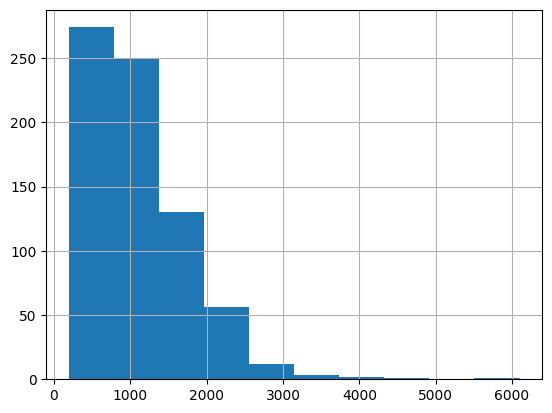

In [22]:
# Distribución del target:
y_train.hist();

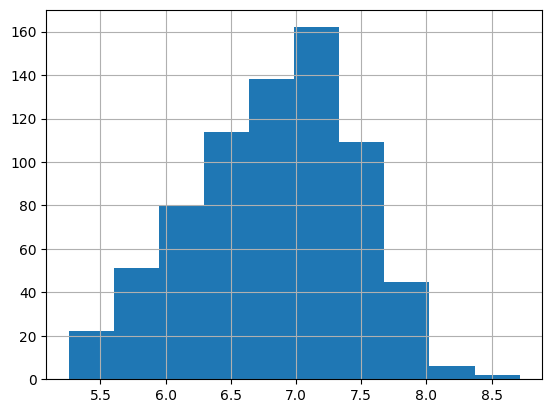

In [23]:
y_train = y_train.apply(np.log)
y_train.hist();

Aplicar inverse transform a las predicciones (ej. np.exp)

In [24]:
X_train.columns

Index(['company', 'product', 'typename', 'inches', 'screenresolution', 'cpu',
       'ram', 'memory', 'gpu', 'opsys', 'weight', 'ram_num', 'weight_num'],
      dtype='object')

In [25]:
print(X_train.typename.value_counts())

typename
Notebook              412
Gaming                113
Ultrabook             113
2 in 1 Convertible     62
Netbook                16
Workstation            13
Name: count, dtype: int64


In [26]:
# ORDINAL ENCODING
from sklearn.preprocessing import OrdinalEncoder
categories_typename= [["Netbook", "Notebook", "2 in 1 Convertible", "Ultrabook", "Gaming", "Workstation"]]
ordinal_encoder_typename = OrdinalEncoder(categories=categories_typename)
X_train["typename_encoded"] = ordinal_encoder_typename.fit_transform(X_train[["typename"]])
X_test["typename_encoded"] = ordinal_encoder_typename.transform(X_test[["typename"]])


In [27]:
features_quitar.append("typename")
features_quitar

['ram', 'weight', 'typename']

In [28]:
mapeo = {
    # grupo 1
    '1366x768':0,
    'touchscreen 1366x768':0,
    'ips panel 1366x768':0,
    'ips panel touchscreen 1366x768':0,
    # grupo 2
    '1440x900':1,
    # grupo 3
    '1600x900':2,
    # grupo 4
    '1920x1080':3,
    'full hd 1920x1080':3,
    'full hd / touchscreen 1920x1080':3,
    'touchscreen / full hd 1920x1080':3,
    'ips panel full hd 1920x1080':3,
    'ips panel full hd / touchscreen 1920x1080':3,
    'ips panel touchscreen 1920x1200':3,
    'ips panel full hd 1920x1200':3,
    # grupo 5
    '2560x1440':4,
    'touchscreen 2560x1440':4,
    'ips panel 2560x1440':4,
    'ips panel touchscreen 2560x1440':4,
    'ips panel full hd 2160x1440':4,
    # grupo 6
    'ips panel retina display 2304x1440':5,
    'touchscreen 2256x1504':5,
    'touchscreen 2400x1600':5,
    'ips panel retina display 2560x1600':5,
    'ips panel retina display 2880x1800':5,
    # grupo 7
    'quad hd+ 3200x1800':6,
    'quad hd+ / touchscreen 3200x1800':6,
    'touchscreen / quad hd+ 3200x1800':6,
    'ips panel quad hd+ / touchscreen 3200x1800':6,
    'ips panel quad hd+ 3200x1800':6,
    # grupo 8
    '4k ultra hd 3840x2160':7,
    '4k ultra hd / touchscreen 3840x2160':7,
    'touchscreen / 4k ultra hd 3840x2160':7,
    'ips panel 4k ultra hd 3840x2160':7,
    'ips panel 4k ultra hd / touchscreen 3840x2160':7
}

X_train["screenresolution_encoded"] = X_train["screenresolution"].map(mapeo)
X_test["screenresolution_encoded"] = X_test["screenresolution"].map(mapeo)

In [29]:
X_train["screenresolution_encoded"].value_counts()

screenresolution_encoded
3    465
0    179
7     21
6     20
2     14
5     13
4     13
1      4
Name: count, dtype: int64

In [30]:
features_quitar.append("screenresolution")
features_quitar

['ram', 'weight', 'typename', 'screenresolution']

In [31]:
X_train.columns

Index(['company', 'product', 'typename', 'inches', 'screenresolution', 'cpu',
       'ram', 'memory', 'gpu', 'opsys', 'weight', 'ram_num', 'weight_num',
       'typename_encoded', 'screenresolution_encoded'],
      dtype='object')

In [32]:
X_train.head()

,company,product,typename,inches,screenresolution,cpu,ram,memory,gpu,opsys,weight,ram_num,weight_num,typename_encoded,screenresolution_encoded
laptop_ID,,,,,,,,,,,,,,,
1118,HP,ZBook 17,Workstation,17.3,ips panel full hd 1920x1080,Intel Core i7 6700HQ 2.6GHz,8GB,1TB HDD,AMD FirePro W6150M,Windows 7,3.0kg,8,3.00,5.0,3
153,Dell,Inspiron 5577,Gaming,15.6,full hd 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1050,Windows 10,2.56kg,16,2.56,4.0,3
275,Apple,MacBook Pro,Ultrabook,13.3,ips panel retina display 2560x1600,Intel Core i5 2.9GHz,8GB,512GB SSD,Intel Iris Graphics 550,macOS,1.37kg,8,1.37,3.0,5
1100,HP,EliteBook 840,Notebook,14.0,full hd 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,500GB HDD,Intel HD Graphics 520,Windows 7,1.54kg,4,1.54,1.0,3
131,Dell,Inspiron 5770,Notebook,17.3,full hd 1920x1080,Intel Core i7 8550U 1.8GHz,16GB,256GB SSD + 2TB HDD,AMD Radeon 530,Windows 10,2.8kg,16,2.80,1.0,3


In [33]:
encoder_company = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Train
encoded_train = encoder_company.fit_transform(X_train[['company']])
encoded_train_df = pd.DataFrame(encoded_train, columns=encoder_company.get_feature_names_out(), index=X_train.index)
X_train = pd.concat([X_train, encoded_train_df], axis=1)

# Test
encoded_test = encoder_company.transform(X_test[['company']])
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder_company.get_feature_names_out(), index=X_test.index)
X_test = pd.concat([X_test, encoded_test_df], axis=1)


c:\Users\Arrate\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


In [34]:
features_quitar.append("company")
# Fuera "product" por su alta cardinalidad.
features_quitar.append("product")
features_quitar

['ram', 'weight', 'typename', 'screenresolution', 'company', 'product']

In [35]:
encoder_opsys = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Train
encoded_train = encoder_opsys.fit_transform(X_train[['opsys']])
encoded_train_df = pd.DataFrame(encoded_train, columns=encoder_opsys.get_feature_names_out(), index=X_train.index)
X_train = pd.concat([X_train, encoded_train_df], axis=1)

# Test
encoded_test = encoder_opsys.transform(X_test[['opsys']])
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder_opsys.get_feature_names_out(), index=X_test.index)
X_test = pd.concat([X_test, encoded_test_df], axis=1)


In [36]:
features_quitar.append("opsys")
X_train = X_train.drop(columns=features_quitar)
X_test = X_test.drop(columns=features_quitar)
X_train.columns

Index(['inches', 'cpu', 'memory', 'gpu', 'ram_num', 'weight_num',
       'typename_encoded', 'screenresolution_encoded', 'company_Apple',
       'company_Asus', 'company_Chuwi', 'company_Dell', 'company_Fujitsu',
       'company_Google', 'company_HP', 'company_Lenovo', 'company_MSI',
       'company_Mediacom', 'company_Microsoft', 'company_Razer',
       'company_Samsung', 'company_Toshiba', 'company_Vero', 'company_Xiaomi',
       'opsys_Chrome OS', 'opsys_Linux', 'opsys_Mac OS X', 'opsys_No OS',
       'opsys_Windows 10', 'opsys_Windows 10 S', 'opsys_Windows 7',
       'opsys_macOS'],
      dtype='object')

In [37]:
X_train[['cpu', 'memory', 'gpu']].head()

,cpu,memory,gpu
laptop_ID,,,
1118,Intel Core i7 6700HQ 2.6GHz,1TB HDD,AMD FirePro W6150M
153,Intel Core i7 7700HQ 2.8GHz,512GB SSD,Nvidia GeForce GTX 1050
275,Intel Core i5 2.9GHz,512GB SSD,Intel Iris Graphics 550
1100,Intel Core i5 6200U 2.3GHz,500GB HDD,Intel HD Graphics 520
131,Intel Core i7 8550U 1.8GHz,256GB SSD + 2TB HDD,AMD Radeon 530


In [38]:
tool.describe_df(X_train[['cpu', 'memory', 'gpu']])

,data_type,valores_nulos,valores_unicos,cardinalidad_ptg
cpu,categorica,0.0,93,12.76
memory,categorica,0.0,33,4.53
gpu,categorica,0.0,84,11.52


In [39]:
for col in ['cpu', 'memory', 'gpu']:
    print(df.groupby(col)[target_str].agg(['mean', 'std', 'count'])
            .sort_values('mean', ascending=False)
            .head(20))

                                      mean          std  count
cpu                                                           
Intel Xeon E3-1535M v5 2.9GHz  4389.000000          NaN      1
Intel Core i7 7820HK 2.9GHz    3879.250000  1572.410119      4
Intel Core i7 6920HQ 2.9GHz    2799.000000          NaN      1
Intel Core i7 6820HK 2.7GHz    2546.328000   896.614130      5
Intel Core i7 2.7GHz           2537.450000          NaN      1
Intel Core i7 2.8GHz           2439.970000          NaN      1
Intel Core i7 7820HQ 2.9GHz    2239.465000   571.681810      4
Intel Core i7 6820HQ 2.7GHz    2219.200000   168.858521      5
Intel Core i7 7660U 2.5GHz     2194.000000   558.614357      2
Intel Core i7 2.2GHz           2139.970000          NaN      1
Intel Core M 6Y75 1.2GHz       2119.500000   710.751011      4
Intel Core i7 6600U 2.6GHz     2112.595556   252.277821      9
Intel Core i7 7700HQ 2.7GHz    2046.000000          NaN      1
Intel Xeon E3-1505M V6 3GHz    1993.000000          NaN

In [40]:
print(df[['memory']].nunique())
print(df['memory'].unique())

memory    37
dtype: int64
['256GB SSD' '1TB HDD' '128GB Flash Storage' '128GB SSD +  1TB HDD'
 '512GB SSD' '500GB HDD' '256GB SSD +  256GB SSD' '128GB SSD'
 '32GB Flash Storage' '64GB Flash Storage' '1.0TB Hybrid' '2TB HDD'
 '256GB Flash Storage' '256GB SSD +  1TB HDD' '180GB SSD'
 '16GB Flash Storage' '1TB SSD' '256GB SSD +  2TB HDD' '32GB SSD'
 '1TB SSD +  1TB HDD' '128GB SSD +  2TB HDD' '512GB SSD +  1TB HDD'
 '512GB SSD +  512GB SSD' '512GB SSD +  256GB SSD' '16GB SSD'
 '64GB Flash Storage +  1TB HDD' '64GB SSD' '128GB HDD' '240GB SSD'
 '512GB SSD +  2TB HDD' '508GB Hybrid' '8GB SSD' '256GB SSD +  500GB HDD'
 '1.0TB HDD' '512GB Flash Storage' '1TB HDD +  1TB HDD' '32GB HDD']


In [41]:
df['memory'] = df['memory'].replace('1.0TB HDD', '1TB HDD')
X_train['memory'] = X_train['memory'].replace('1.0TB HDD', '1TB HDD')
X_test['memory'] = X_test['memory'].replace('1.0TB HDD', '1TB HDD')


In [42]:
categorias_memory = [[
    '8GB SSD',
    '16GB SSD',
    '16GB Flash Storage',
    '32GB HDD',
    '32GB SSD',
    '32GB Flash Storage',
    '64GB SSD',
    '64GB Flash Storage',
    '128GB HDD',
    '128GB Flash Storage',
    '128GB SSD',
    '180GB SSD',
    '240GB SSD',
    '256GB Flash Storage',
    '256GB SSD',
    '500GB HDD',
    '508GB Hybrid',
    '256GB SSD +  256GB SSD',
    '512GB Flash Storage',
    '512GB SSD',
    '256GB SSD +  500GB HDD',
    '512GB SSD +  256GB SSD',
    '1.0TB Hybrid',
    '1TB HDD',
    '1TB SSD',
    '256GB SSD +  1.0TB Hybrid',  
    '512GB SSD +  512GB SSD',
    '64GB Flash Storage +  1TB HDD',
    '128GB SSD +  1TB HDD',
    '256GB SSD +  1TB HDD',
    '512GB SSD +  1.0TB Hybrid',   
    '512GB SSD +  1TB HDD',
    '2TB HDD',
    '1TB HDD +  1TB HDD',
    '1TB SSD +  1TB HDD',
    '128GB SSD +  2TB HDD',
    '256GB SSD +  2TB HDD',
    '512GB SSD +  2TB HDD',
]]
ordinal_encoder_memory = OrdinalEncoder(categories=categorias_memory)
X_train["memory_encoded"] = ordinal_encoder_memory.fit_transform(X_train[["memory"]])
X_test["memory_encoded"] = ordinal_encoder_memory.transform(X_test[["memory"]])



In [43]:
X_train = X_train.drop("memory", axis=1)
X_test = X_test.drop("memory", axis=1)
X_train.columns

Index(['inches', 'cpu', 'gpu', 'ram_num', 'weight_num', 'typename_encoded',
       'screenresolution_encoded', 'company_Apple', 'company_Asus',
       'company_Chuwi', 'company_Dell', 'company_Fujitsu', 'company_Google',
       'company_HP', 'company_Lenovo', 'company_MSI', 'company_Mediacom',
       'company_Microsoft', 'company_Razer', 'company_Samsung',
       'company_Toshiba', 'company_Vero', 'company_Xiaomi', 'opsys_Chrome OS',
       'opsys_Linux', 'opsys_Mac OS X', 'opsys_No OS', 'opsys_Windows 10',
       'opsys_Windows 10 S', 'opsys_Windows 7', 'opsys_macOS',
       'memory_encoded'],
      dtype='object')

El doble corchete [[ ]] es porque OrdinalEncoder está diseñado para encodear varias columnas a la vez, y cada elemento de categories corresponde a una columna. Como solo paso memory, necesito envolver la lista en otra lista.

Target Encoding reemplaza cada categoría por la media del target para esa categoría.  Es muy útil para alta cardinalidad porque evita el problema de one-hot encoding (que generaría muchas columnas).  
El target encoding es propenso a leakage si no se hace bien. TargetEncoder de sklearn lo maneja internamente usando cross-fitting en el train para evitarlo, por eso es importante usar fit_transform solo sobre train y transform sobre test. 

In [44]:
from sklearn.preprocessing import TargetEncoder
target_encoder = TargetEncoder()

X_train[['cpu_encoded', 'gpu_encoded']] = target_encoder.fit_transform(
    X_train[['cpu', 'gpu']], y_train
)

X_test[['cpu_encoded', 'gpu_encoded']] = target_encoder.transform(
    X_test[['cpu', 'gpu']]
)

In [45]:
X_train = X_train.drop(columns= ["cpu","gpu"])

In [46]:
X_train.columns

Index(['inches', 'ram_num', 'weight_num', 'typename_encoded',
       'screenresolution_encoded', 'company_Apple', 'company_Asus',
       'company_Chuwi', 'company_Dell', 'company_Fujitsu', 'company_Google',
       'company_HP', 'company_Lenovo', 'company_MSI', 'company_Mediacom',
       'company_Microsoft', 'company_Razer', 'company_Samsung',
       'company_Toshiba', 'company_Vero', 'company_Xiaomi', 'opsys_Chrome OS',
       'opsys_Linux', 'opsys_Mac OS X', 'opsys_No OS', 'opsys_Windows 10',
       'opsys_Windows 10 S', 'opsys_Windows 7', 'opsys_macOS',
       'memory_encoded', 'cpu_encoded', 'gpu_encoded'],
      dtype='object')

In [47]:
X_test = X_test.drop(columns= ["cpu","gpu"])

In [48]:
len(X_train.columns) == len(X_test.columns)

True

In [49]:
X_train.head(2)

,inches,ram_num,weight_num,typename_encoded,screenresolution_encoded,company_Apple,company_Asus,company_Chuwi,company_Dell,company_Fujitsu,...,opsys_Linux,opsys_Mac OS X,opsys_No OS,opsys_Windows 10,opsys_Windows 10 S,opsys_Windows 7,opsys_macOS,memory_encoded,cpu_encoded,gpu_encoded
laptop_ID,,,,,,,,,,,,,,,,,,,,,
1118,17.3,8,3.00,5.0,3,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,23.0,7.317103,6.810647
153,15.6,16,2.56,4.0,3,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,19.0,7.365254,7.070399


Todas las columnas a minúsculas.
Ram --> Quitarle GB en una columna nueva y convertir a int.  
Weight --> Quitarle kg en una columna nueva y convertir a float.   
TypeName -->Encoding ordenada. Netbook < Notebook < 2 in 1 Convertible < Ultrabook < Gaming < Workstation.  
ScreenResolution -->Encoding ordenada mediante mapeo.    
Company, opsys --> One-Hot-encoding.    
 Product--> ¿Me la quedo? Tiene alta cardinalidad, posibilidad de convertir en bins según Company. ¿Cómo puedo hacer esto? NO ME LA QUEDO.    
Cpu --> One-Hot-encoding.???   



In [50]:
print(X_train.describe().T)

                          count       mean       std        min        25%  \
inches                    729.0  15.002881  1.428711  10.100000  14.000000   
ram_num                   729.0   8.233196  4.986294   2.000000   4.000000   
weight_num                729.0   2.033752  0.668108   0.690000   1.500000   
typename_encoded          729.0   1.909465  1.257955   0.000000   1.000000   
screenresolution_encoded  729.0   2.484225  1.669074   0.000000   1.000000   
company_Apple             729.0   0.017833  0.132434   0.000000   0.000000   
company_Asus              729.0   0.138546  0.345709   0.000000   0.000000   
company_Chuwi             729.0   0.001372  0.037037   0.000000   0.000000   
company_Dell              729.0   0.216735  0.412304   0.000000   0.000000   
company_Fujitsu           729.0   0.002743  0.052342   0.000000   0.000000   
company_Google            729.0   0.002743  0.052342   0.000000   0.000000   
company_HP                729.0   0.212620  0.409442   0.000000 

In [51]:
from sklearn.preprocessing import StandardScaler

cols_to_scale = [
    'inches', 'ram_num', 'weight_num',
    'typename_encoded', 'screenresolution_encoded',
    'memory_encoded', 'cpu_encoded', 'gpu_encoded'
]

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_test_scaled[cols_to_scale] = scaler.transform(X_test[cols_to_scale])

In [52]:
X_train_scaled.columns

Index(['inches', 'ram_num', 'weight_num', 'typename_encoded',
       'screenresolution_encoded', 'company_Apple', 'company_Asus',
       'company_Chuwi', 'company_Dell', 'company_Fujitsu', 'company_Google',
       'company_HP', 'company_Lenovo', 'company_MSI', 'company_Mediacom',
       'company_Microsoft', 'company_Razer', 'company_Samsung',
       'company_Toshiba', 'company_Vero', 'company_Xiaomi', 'opsys_Chrome OS',
       'opsys_Linux', 'opsys_Mac OS X', 'opsys_No OS', 'opsys_Windows 10',
       'opsys_Windows 10 S', 'opsys_Windows 7', 'opsys_macOS',
       'memory_encoded', 'cpu_encoded', 'gpu_encoded'],
      dtype='object')

-----------------------------------------------------------------------------------------------------------------

## 4. Modelado

In [53]:
df[target_str].describe()

count     912.000000
mean     1111.724090
std       687.959172
min       174.000000
25%       589.000000
50%       978.000000
75%      1483.942500
max      6099.000000
Name: price_in_euros, dtype: float64

### 4.2 Sacar métricas, valorar los modelos

Recuerda que en la competición se va a evaluar con la métrica de ``RMSE``.

### 4.3 Optimización (up to you 🫰🏻)

In [54]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR

forest_reg = RandomForestRegressor(max_depth= 5, random_state=42)
gbr = GradientBoostingRegressor(max_depth=5)
svr = SVR(kernel="rbf")

In [55]:
model_names = ["RandomForestRegressor", "GradientBoostingRegressor", "SVR"]
model_set = [ forest_reg, gbr, svr]
metricas_cv = {}
valores = []
for nombre,modelo in zip(model_names, model_set):
    print(type(modelo).__name__)
    metricas_cv[nombre] = cross_val_score(modelo, X_train_scaled, y_train, cv = 5, scoring = "neg_mean_squared_error", verbose= 0)
    valores.append(np.mean(metricas_cv[nombre]))
ganador = list(metricas_cv.keys())[np.argmin(np.abs(valores))]

RandomForestRegressor
GradientBoostingRegressor
SVR


In [56]:
for model_name, valores in metricas_cv.items():
    print(f"Model <{model_name}>, RMSE: {np.sqrt(np.abs(valores))}")
    print(f"{model_name} → RMSE medio: {(np.sqrt(np.abs(valores))).mean():.4f} | Std: {(np.sqrt(np.abs(valores))).std():.4f}")
print(f"El ganador es {ganador}")

Model <RandomForestRegressor>, RMSE: [0.25933073 0.23027811 0.22876523 0.25870384 0.25593941]
RandomForestRegressor → RMSE medio: 0.2466 | Std: 0.0140
Model <GradientBoostingRegressor>, RMSE: [0.19683084 0.20670989 0.20239795 0.21947792 0.21959821]
GradientBoostingRegressor → RMSE medio: 0.2090 | Std: 0.0092
Model <SVR>, RMSE: [0.22427915 0.22488822 0.23908943 0.22213127 0.25707825]
SVR → RMSE medio: 0.2335 | Std: 0.0132
El ganador es GradientBoostingRegressor


In [57]:
forest_reg.fit(X_train_scaled, y_train)
forest_reg.feature_importances_

array([2.13795201e-02, 4.58211133e-01, 3.40703552e-02, 1.25552873e-01,
       2.45786261e-02, 0.00000000e+00, 1.46607771e-03, 0.00000000e+00,
       3.80740691e-04, 0.00000000e+00, 0.00000000e+00, 8.55227451e-04,
       8.75243915e-04, 0.00000000e+00, 6.00092371e-06, 5.48652109e-06,
       1.87199480e-04, 0.00000000e+00, 3.93055693e-04, 9.35145961e-07,
       0.00000000e+00, 1.83507826e-04, 2.07568465e-04, 8.76551871e-06,
       1.04759044e-03, 3.51383824e-03, 0.00000000e+00, 1.31113859e-03,
       0.00000000e+00, 6.91490680e-03, 1.97908115e-01, 1.20942094e-01])

In [58]:
# Seleccionar features con importancia mayor a un umbral
umbral = 0.01  # 1%, ajusta según quieras
importances = pd.Series(forest_reg.feature_importances_, index=X_train.columns)
cols_importantes = importances[importances > umbral].index.tolist()
print(cols_importantes)

# Filtrar train y test con las mismas columnas
X_train_filtrado = X_train[cols_importantes]
X_test_filtrado = X_test[cols_importantes]

['inches', 'ram_num', 'weight_num', 'typename_encoded', 'screenresolution_encoded', 'cpu_encoded', 'gpu_encoded']


In [59]:
from sklearn.model_selection import GridSearchCV
gbr = GradientBoostingRegressor(random_state=42)
params_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5],
    'min_samples_split': [2, 5, 10],
    'subsample': [0.8, 1.0]
}

grid_gbr = GridSearchCV(gbr,
                       param_grid= params_grid,
                       cv =5, 
                       scoring= "neg_mean_squared_error",
                       n_jobs= -1,
                       verbose=0)

grid_gbr.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation ti

In [60]:
print(grid_gbr.best_params_)
print(f"Mejor RMSE cv: {np.sqrt(-grid_gbr.best_score_):.4f}")

{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 300, 'subsample': 0.8}
Mejor RMSE cv: 0.1989


In [61]:
y_pred= np.exp(grid_gbr.best_estimator_.predict(X_test))

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"RMSE en test (escala original): {rmse_test:.2f} €")

RMSE en test (escala original): 277.37 €


In [62]:
gbr_2 = GradientBoostingRegressor(random_state=42)
params_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 4, 5, 10],
    'min_samples_split': [2, 5, 10, 15],
    'subsample': [0.8, 1.0]
}

grid_gbr_2 = GridSearchCV(gbr_2,
                       param_grid= params_grid,
                       cv =5, 
                       scoring= "neg_mean_squared_error",
                       n_jobs= -1,
                       verbose=0)

grid_gbr_2.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",GradientBoost...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'learning_rate': [0.05, 0.1, ...], 'max_depth': [3, 4, ...], 'min_samples_split': [2, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_mean_squared_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation ti

In [63]:
y_pred_2= np.exp(grid_gbr_2.best_estimator_.predict(X_test))

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_2))
print(f"RMSE en test (escala original): {rmse_test:.2f} €")

RMSE en test (escala original): 276.74 €


In [64]:
print(grid_gbr_2.best_params_)

{'learning_rate': 0.05, 'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 500, 'subsample': 0.8}


In [65]:
from xgboost import XGBRFRegressor

xgbrf = XGBRFRegressor(random_state=42)

params_grid_xgbrf = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 4, 5, 10],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bynode': [0.8, 1.0]  # equivalente a max_features en RF
}

grid_xgbrf = GridSearchCV(xgbrf,
                           param_grid=params_grid_xgbrf,
                           cv=5,
                           scoring="neg_mean_squared_error",
                           n_jobs=-1,
                           verbose=0)

grid_xgbrf.fit(X_train_scaled, y_train)
print(grid_xgbrf.best_params_) 
print(f"Mejor RMSE cv: {np.sqrt(-grid_xgbrf.best_score_):.4f}")   

{'colsample_bynode': 1.0, 'learning_rate': 0.2, 'max_depth': 10, 'n_estimators': 300, 'subsample': 1.0}
Mejor RMSE cv: 0.5129


In [66]:
y_pred_xgbrf = np.exp(grid_xgbrf.best_estimator_.predict(X_test_scaled))

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_xgbrf))
print(f"RMSE en test (escala original): {rmse_test:.2f} €")

RMSE en test (escala original): 677.57 €


-----------------------------------------------------------------

## Una vez listo el modelo, toca predecir ``test.csv``

**RECUERDA: APLICAR LAS TRANSFORMACIONES QUE HAYAS REALIZADO EN `train.csv` a `test.csv`.**


Véase:
- Estandarización/Normalización
- Eliminación de Outliers
- Eliminación de columnas
- Creación de columnas nuevas
- Gestión de valores nulos
- Y un largo etcétera de técnicas que como Data Scientist hayas considerado las mejores para tu dataset.

## 1. Carga los datos de `test.csv` para predecir.


In [84]:
X_pred = pd.read_csv("./data/test.csv", index_col= "laptop_ID")
X_pred.head()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
209,Lenovo,Legion Y520-15IKBN,Gaming,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD,Nvidia GeForce GTX 1060,No OS,2.4kg
1281,Acer,Aspire ES1-531,Notebook,15.6,1366x768,Intel Celeron Dual Core N3060 1.6GHz,4GB,500GB HDD,Intel HD Graphics 400,Linux,2.4kg
1168,Lenovo,V110-15ISK (i3-6006U/4GB/1TB/No,Notebook,15.6,1366x768,Intel Core i3 6006U 2.0GHz,4GB,1TB HDD,Intel HD Graphics 520,No OS,1.9kg
1231,Dell,Inspiron 7579,2 in 1 Convertible,15.6,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,2.191kg
1020,HP,ProBook 640,Notebook,14.0,Full HD 1920x1080,Intel Core i5 7200U 2.5GHz,4GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.95kg


In [85]:
X_pred.tail()

,Company,Product,TypeName,Inches,ScreenResolution,Cpu,Ram,Memory,Gpu,OpSys,Weight
laptop_ID,,,,,,,,,,,
820,MSI,GE72MVR 7RG,Gaming,17.3,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,16GB,512GB SSD + 1TB HDD,Nvidia GeForce GTX 1070,Windows 10,2.9kg
948,Toshiba,Tecra Z40-C-12X,Notebook,14.0,IPS Panel Full HD 1920x1080,Intel Core i5 6200U 2.3GHz,4GB,128GB SSD,Intel HD Graphics 520,Windows 10,1.47kg
483,Dell,Precision M5520,Workstation,15.6,Full HD 1920x1080,Intel Core i7 7700HQ 2.8GHz,8GB,256GB SSD,Nvidia Quadro M1200,Windows 10,1.78kg
1017,HP,Probook 440,Notebook,14.0,1366x768,Intel Core i5 7200U 2.5GHz,4GB,500GB HDD,Intel HD Graphics 620,Windows 10,1.64kg
421,Asus,ZenBook Flip,2 in 1 Convertible,13.3,IPS Panel Full HD / Touchscreen 1920x1080,Intel Core i5 7200U 2.5GHz,8GB,256GB SSD,Intel HD Graphics 620,Windows 10,1.27kg


In [69]:
X_pred.info()

<class 'pandas.core.frame.DataFrame'>
Index: 391 entries, 209 to 421
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Company           391 non-null    object 
 1   Product           391 non-null    object 
 2   TypeName          391 non-null    object 
 3   Inches            391 non-null    float64
 4   ScreenResolution  391 non-null    object 
 5   Cpu               391 non-null    object 
 6   Ram               391 non-null    object 
 7   Memory            391 non-null    object 
 8   Gpu               391 non-null    object 
 9   OpSys             391 non-null    object 
 10  Weight            391 non-null    object 
dtypes: float64(1), object(10)
memory usage: 36.7+ KB


 ## 2. Replicar el procesado para ``test.csv``

In [86]:
X_pred
X_pred.columns = X_pred.columns.str.lower()

X_pred["ram_num"]= X_pred["ram"].str.replace("GB", "")
X_pred["ram_num"] = X_pred["ram_num"].astype(int)
X_pred["weight"]= X_pred["weight"].str.lower()
X_pred["weight_num"]= X_pred["weight"].str.replace("kg", "")
X_pred["weight_num"] = X_pred["weight_num"].astype(float)
X_pred["screenresolution"] = X_pred["screenresolution"].str.lower()

X_pred["typename_encoded"] = ordinal_encoder_typename.transform(X_pred[["typename"]])

X_pred["screenresolution_encoded"] = X_pred["screenresolution"].map(mapeo)

encoded_test = encoder_company.transform(X_pred[['company']])
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder_company.get_feature_names_out(), index=X_pred.index)
X_pred = pd.concat([X_pred, encoded_test_df], axis=1)

encoded_test = encoder_opsys.transform(X_pred[['opsys']])
encoded_test_df = pd.DataFrame(encoded_test, columns=encoder_opsys.get_feature_names_out(), index=X_pred.index)
X_pred = pd.concat([X_pred, encoded_test_df], axis=1)

X_pred['memory'] = X_pred['memory'].replace('1.0TB HDD', '1TB HDD')
X_pred["memory_encoded"] = ordinal_encoder_memory.transform(X_pred[["memory"]])

X_pred[['cpu_encoded', 'gpu_encoded']] = target_encoder.transform(X_pred[['cpu', 'gpu']])





c:\Users\Arrate\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\preprocessing\_encoders.py:261: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(msg, UserWarning)


Como no he entrenado con el modelo escalado, no tengo que escalar X_pred

In [87]:
features_quitar = ["ram"]
features_quitar.append("weight")
features_quitar.append("typename")
features_quitar.append("screenresolution")
features_quitar.append("company")
features_quitar.append("opsys")
features_quitar.append("memory")
features_quitar.append("cpu")
features_quitar.append("gpu")
X_pred = X_pred.drop(columns=features_quitar)
X_pred= X_pred.drop(columns=['product'])

In [88]:
X_pred.isna().sum()

inches                      0
ram_num                     0
weight_num                  0
typename_encoded            0
screenresolution_encoded    5
company_Apple               0
company_Asus                0
company_Chuwi               0
company_Dell                0
company_Fujitsu             0
company_Google              0
company_HP                  0
company_Lenovo              0
company_MSI                 0
company_Mediacom            0
company_Microsoft           0
company_Razer               0
company_Samsung             0
company_Toshiba             0
company_Vero                0
company_Xiaomi              0
opsys_Chrome OS             0
opsys_Linux                 0
opsys_Mac OS X              0
opsys_No OS                 0
opsys_Windows 10            0
opsys_Windows 10 S          0
opsys_Windows 7             0
opsys_macOS                 0
memory_encoded              0
cpu_encoded                 0
gpu_encoded                 0
dtype: int64

In [89]:
media = X_train["screenresolution_encoded"].mean()
X_pred["screenresolution_encoded"] = X_pred["screenresolution_encoded"].fillna(media)

Aplicar inverse transform a las predicciones (ej. np.exp), porque hemos transformado el target.

In [90]:
predictions_submit =np.exp(grid_gbr.best_estimator_.predict(X_pred))
predictions_submit

array([1728.09415912,  293.54629658,  377.86732073,  922.3810036 ,
       1069.96115916,  445.90499536,  768.52876295,  990.22003628,
       1101.73880006,  311.96695731, 2272.87313825, 1380.14698198,
        512.22784692, 1409.09428439,  847.77293667,  770.85528901,
       2341.60922891, 1258.670417  , 2331.12827896,  608.19279021,
       1885.7565248 ,  273.16684113,  730.94642155, 1322.30333684,
        466.03888844,  721.92197898,  550.25110236,  917.96639914,
       3151.8526924 , 1013.51495479, 2486.69955375,  434.95437067,
        851.23823788, 3073.41244028, 2043.05435746, 1496.40233682,
        626.20734821, 1446.28140217, 1009.95010881, 1464.30487252,
        670.76189951,  944.5063198 ,  526.21193576, 1305.97339468,
       1124.04680558, 1018.12119053,  954.41653497,  550.87824498,
        662.31924979,  367.9947409 , 1599.39849132,  839.90610727,
       1088.88481911,  398.30684931, 1884.57375589, 1906.79770641,
        597.9316669 ,  970.25615447,  986.11382381,  693.08646

In [91]:
print(X_train.shape, X_pred.shape)
print(set(X_train.columns) - set(X_pred.columns))  # columnas que faltan en X_pred
print(set(X_pred.columns) - set(X_train.columns))  # columnas extra en X_pred

(729, 32) (391, 32)
set()
set()


In [92]:
X_pred.describe()

,inches,ram_num,weight_num,typename_encoded,screenresolution_encoded,company_Apple,company_Asus,company_Chuwi,company_Dell,company_Fujitsu,...,opsys_Linux,opsys_Mac OS X,opsys_No OS,opsys_Windows 10,opsys_Windows 10 S,opsys_Windows 7,opsys_macOS,memory_encoded,cpu_encoded,gpu_encoded
count,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,...,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000,391.000000
mean,15.100256,8.659847,2.066248,1.938619,2.607215,0.010230,0.094629,0.002558,0.255754,0.002558,...,0.035806,0.005115,0.056266,0.846547,0.002558,0.040921,0.005115,18.672634,6.870654,6.857996
std,1.400009,5.172352,0.665533,1.265445,1.588425,0.100755,0.293077,0.050572,0.436843,0.050572,...,0.186043,0.071428,0.230730,0.360885,0.050572,0.198360,0.071428,6.696363,0.477416,0.453839
min,10.100000,2.000000,0.690000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000,5.350910,5.672127
25%,14.000000,4.000000,1.600000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,14.000000,6.733833,6.758651
50%,15.600000,8.000000,2.040000,1.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,15.000000,6.925875,6.900029
75%,15.600000,8.000000,2.320000,3.000000,3.000000,0.000000,0.000000,0.000000,1.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,23.000000,7.097193,7.040694
max,17.300000,32.000000,4.600000,5.000000,7.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,37.000000,8.119112,8.388578


**¡OJO! ¿Por qué me da error?**

IMPORTANTE:

- SI EL ARRAY CON EL QUE HICISTEIS `.fit()` ERA DE 4 COLUMNAS, PARA `.predict()` DEBEN SER LAS MISMAS
- SI AL ARRAY CON EL QUE HICISTEIS `.fit()` LO NORMALIZASTEIS, PARA `.predict()` DEBÉIS NORMALIZARLO
- TODO IGUAL SALVO **BORRAR FILAS**, EL NÚMERO DE ROWS SE DEBE MANTENER EN ESTE SET, PUES LA PREDICCIÓN DEBE TENER **391 FILAS**, SI O SI

**Entonces, si al cargar los datos de ``train.csv`` usaste `index_col=0`, ¿tendré que hacer lo también para el `test.csv`?**

In [ ]:
# ¿Qué opináis?
# ¿Sí, no? Si

In [102]:
X_pred["Price_in_euros"] = predictions_submit
X_pred.columns

Index(['inches', 'ram_num', 'weight_num', 'typename_encoded',
       'screenresolution_encoded', 'company_Apple', 'company_Asus',
       'company_Chuwi', 'company_Dell', 'company_Fujitsu', 'company_Google',
       'company_HP', 'company_Lenovo', 'company_MSI', 'company_Mediacom',
       'company_Microsoft', 'company_Razer', 'company_Samsung',
       'company_Toshiba', 'company_Vero', 'company_Xiaomi', 'opsys_Chrome OS',
       'opsys_Linux', 'opsys_Mac OS X', 'opsys_No OS', 'opsys_Windows 10',
       'opsys_Windows 10 S', 'opsys_Windows 7', 'opsys_macOS',
       'memory_encoded', 'cpu_encoded', 'gpu_encoded', 'Price_in_euros'],
      dtype='object')

In [103]:
X_pred = X_pred["Price_in_euros"].copy()
X_pred.head()

laptop_ID
209     1728.094159
1281     293.546297
1168     377.867321
1231     922.381004
1020    1069.961159
Name: Price_in_euros, dtype: float64

## 3. **¿Qué es lo que subirás a Kaggle?**

**Para subir a Kaggle la predicción esta tendrá que tener una forma específica.**

En este caso, la **MISMA** forma que `sample_submission.csv`.

In [132]:
sample = pd.read_csv("data/sample_submission.csv")

In [101]:
sample.head()

,Price_in_euros
laptop_ID,
209,1949.1
1281,805.0
1168,1101.0
1231,1293.8
1020,1832.6


In [133]:
sample.shape

(391, 2)

In [96]:
sample.columns

Index(['laptop_ID', 'Price_in_euros'], dtype='object')

## 4. Mete tus predicciones en un dataframe llamado ``submission``.

In [123]:
#¿Cómo creamos la submission?
submission =pd.DataFrame(X_pred)


In [124]:
submission = pd.DataFrame({
    'laptop_ID': X_pred.index,
    'price_in_euros': predictions_submit
}).reset_index(drop=True)

submission

,laptop_ID,price_in_euros
0,209,1728.094159
1,1281,293.546297
2,1168,377.867321
3,1231,922.381004
4,1020,1069.961159
...,...,...
386,820,2264.307534
387,948,1001.826313
388,483,1829.386379
389,1017,858.849387


In [125]:
submission.head()

,laptop_ID,price_in_euros
0,209,1728.094159
1,1281,293.546297
2,1168,377.867321
3,1231,922.381004
4,1020,1069.961159


In [128]:
submission.shape

(391, 2)

## 5. Pásale el CHEQUEADOR para comprobar que efectivamente está listo para subir a Kaggle.

In [129]:
def chequeador(df_to_submit):
    """
    Esta función se asegura de que tu submission tenga la forma requerida por Kaggle.

    Si es así, se guardará el dataframe en un `csv` y estará listo para subir a Kaggle.

    Si no, LEE EL MENSAJE Y HAZLE CASO.

    Si aún no:
    - apaga tu ordenador,
    - date una vuelta,
    - enciendelo otra vez,
    - abre este notebook y
    - leelo todo de nuevo.
    Todos nos merecemos una segunda oportunidad. También tú.
    """
    if df_to_submit.shape == sample.shape:
        if df_to_submit.columns.all() == sample.columns.all():
            if df_to_submit.laptop_ID.all() == sample.laptop_ID.all():
                print("You're ready to submit!")
                df_to_submit.to_csv("submission.csv", index = False) #muy importante el index = False
                urllib.request.urlretrieve("https://www.mihaileric.com/static/evaluation-meme-e0a350f278a36346e6d46b139b1d0da0-ed51e.jpg", "gfg.png")
                img = Image.open("gfg.png")
                img.show()
            else:
                print("Check the ids and try again")
        else:
            print("Check the names of the columns and try again")
    else:
        print("Check the number of rows and/or columns and try again")
        print("\nMensaje secreto del TA: No me puedo creer que después de todo este notebook hayas hecho algún cambio en las filas de `test.csv`. Lloro.")

In [134]:
chequeador(submission)

You're ready to submit!
